In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import re

In [ ]:
DATA_DIR = "../mango_data"
def natural_sort_key(s):
    return [int(c) if c.isdigit() else c for c in re.split(r'(\d+)', s)] 
image_files = sorted(
    [f for f in os.listdir(DATA_DIR) if f.endswith(('.jpg', '.png'))],
    key=natural_sort_key
)
print(f"Tổng số ảnh: {len(image_files)}")
print(image_files)

Tổng số ảnh: 22
['1.jpg', '2.jpg', '3.png', '4.png', '5.png', '6.png', '7.png', '8.png', '9.png', '10.png', '11.png', '12.png', '13.png', '14.png', '15.png', '16.png', '17.png', '18.png', '19.png', '20.png', '21.png', '22.png']


In [4]:
# Nhãn: 0 = Ngọt (vỏ vàng/đỏ), 1 = Chua (vỏ xanh)
labels = {
    "1.jpg":  0,   # Ngọt
    "2.jpg":  1,   # Chua
    "3.png":  0,
    "4.png":  0,
    "5.png":  0,
    "6.png":  0,
    "7.png":  0,
    "8.png":  0,
    "9.png":  0,
    "10.png": 1,
    "11.png": 1,
    "12.png": 1,
    "13.png": 1,
    "14.png": 1,
    "15.png": 1,
    "16.png": 1,
    "17.png": 1,
    "18.png": 1,
    "19.png": 0,
    "20.png": 0,
    "21.png": 0,
    "22.png": 0,
}


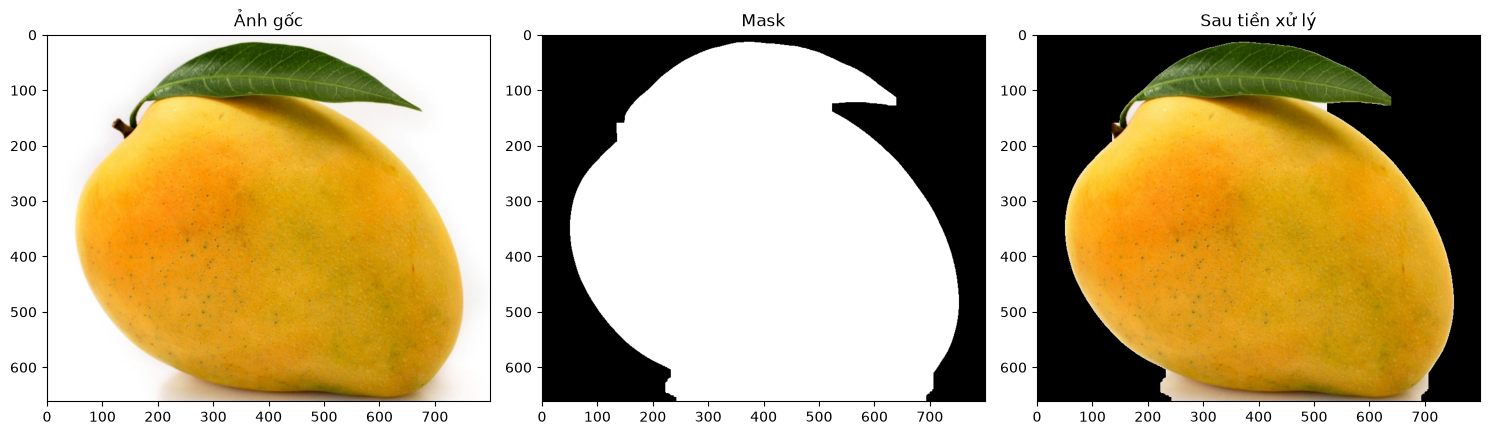

In [5]:
def preprocess_mango(image_path):
    """
    Trích riêng vùng chứa quả xoài:
    - Giữ nguyên màu vùng quả xoài
    - Chuyển nền thành màu đen
    """
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Chuyển sang HSV để dễ tách màu xoài
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Tạo mask cho màu xoài (vàng-xanh lá)
    # Màu xanh lá (xoài chua)
    lower_green = np.array([25, 40, 40])
    upper_green = np.array([85, 255, 255])
    
    # Màu vàng-cam (xoài ngọt)
    lower_yellow = np.array([15, 40, 40])
    upper_yellow = np.array([35, 255, 255])
    
    mask_green  = cv2.inRange(img_hsv, lower_green, upper_green)
    mask_yellow = cv2.inRange(img_hsv, lower_yellow, upper_yellow)
    
    # Kết hợp 2 mask
    mask = cv2.bitwise_or(mask_green, mask_yellow)
    
    # Morphological để lấp lỗ hổng
    kernel = np.ones((15, 15), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    # Lấy contour lớn nhất (thân quả xoài)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        final_mask = np.zeros_like(mask)
        cv2.drawContours(final_mask, [largest], -1, 255, -1)
    else:
        final_mask = mask
    
    # Áp mask vào ảnh gốc (nền → đen)
    result = cv2.bitwise_and(img_rgb, img_rgb, mask=final_mask)
    return result, final_mask

# Test thử với ảnh đầu tiên
img_path = os.path.join(DATA_DIR, image_files[0])
result, mask = preprocess_mango(img_path)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB))
axes[0].set_title("Ảnh gốc")
axes[1].imshow(mask, cmap='gray')
axes[1].set_title("Mask")
axes[2].imshow(result)
axes[2].set_title("Sau tiền xử lý")
plt.tight_layout()
plt.show()


In [6]:
def extract_ratio_green(processed_img):
    """
    Tính ratio_green = sumG / (sumR + sumG + sumB)
    Chỉ tính trên các pixel không phải nền đen (mask > 0)
    """
    R = processed_img[:, :, 0].astype(np.float64)
    G = processed_img[:, :, 1].astype(np.float64)
    B = processed_img[:, :, 2].astype(np.float64)
    
    # Chỉ lấy pixel thuộc quả xoài (khác [0,0,0])
    pixel_mask = (R + G + B) > 0
    
    sumR = R[pixel_mask].sum()
    sumG = G[pixel_mask].sum()
    sumB = B[pixel_mask].sum()
    sumRGB = sumR + sumG + sumB
    
    if sumRGB == 0:
        return 0.0
    
    ratio_green = sumG / sumRGB
    return ratio_green

# ---- Ví dụ tính tay từ đề bài ----
R_ex = np.array([[200, 180], [150, 160], [170, 190]])
G_ex = np.array([[50,  70],  [120, 100], [80,  60]])
B_ex = np.array([[30,  20],  [40,  30],  [20,  10]])

sumR_ex = R_ex.sum()  # 1050
sumG_ex = G_ex.sum()  # 480
sumB_ex = B_ex.sum()  # 150
ratio_ex = sumG_ex / (sumR_ex + sumG_ex + sumB_ex)
print(f"Ví dụ: sumR={sumR_ex}, sumG={sumG_ex}, sumB={sumB_ex}")
print(f"ratio_green = {ratio_ex:.4f}")  # ≈ 0.2857


Ví dụ: sumR=1050, sumG=480, sumB=150
ratio_green = 0.2857


1.jpg        | ratio_green=0.3942 | label=Ngọt
2.jpg        | ratio_green=0.3654 | label=Chua
3.png        | ratio_green=0.3764 | label=Ngọt
4.png        | ratio_green=0.3761 | label=Ngọt
5.png        | ratio_green=0.3738 | label=Ngọt
6.png        | ratio_green=0.3824 | label=Ngọt
7.png        | ratio_green=0.3707 | label=Ngọt
8.png        | ratio_green=0.3714 | label=Ngọt
9.png        | ratio_green=0.3738 | label=Ngọt
10.png       | ratio_green=0.4055 | label=Chua
11.png       | ratio_green=0.4304 | label=Chua
12.png       | ratio_green=0.4598 | label=Chua
13.png       | ratio_green=0.4442 | label=Chua
14.png       | ratio_green=0.4044 | label=Chua
15.png       | ratio_green=0.4263 | label=Chua
16.png       | ratio_green=0.4078 | label=Chua
17.png       | ratio_green=0.3923 | label=Chua
18.png       | ratio_green=0.4185 | label=Chua
19.png       | ratio_green=0.0000 | label=Ngọt
20.png       | ratio_green=0.3450 | label=Ngọt
21.png       | ratio_green=0.3669 | label=Ngọt
22.png       

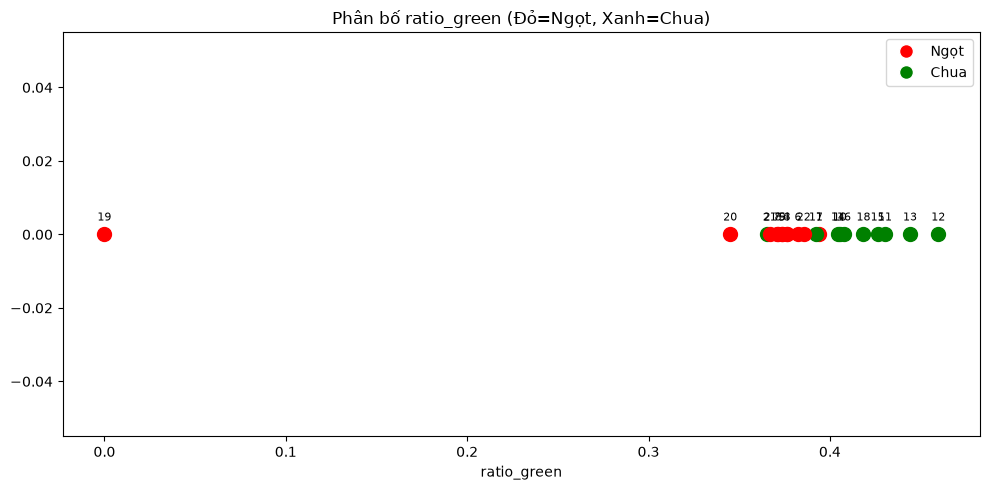

In [7]:
# ---- Trích đặc trưng toàn bộ ảnh ----
all_features = []
all_labels   = []

for fname in image_files:
    img_path = os.path.join(DATA_DIR, fname)
    processed, _ = preprocess_mango(img_path)
    rg = extract_ratio_green(processed)
    lbl = labels[fname]
    all_features.append(rg)
    all_labels.append(lbl)
    print(f"{fname:12s} | ratio_green={rg:.4f} | label={'Ngọt' if lbl==0 else 'Chua'}")

all_features = np.array(all_features)
all_labels   = np.array(all_labels)

# ---- Vẽ phân bố đặc trưng ----
fig, ax = plt.subplots(figsize=(10, 5))
for i, (rg, lbl, fname) in enumerate(zip(all_features, all_labels, image_files)):
    color = 'red' if lbl == 0 else 'green'
    label_str = 'Ngọt' if lbl == 0 else 'Chua'
    ax.scatter(rg, 0, color=color, s=100, zorder=5)
    ax.annotate(fname.split('.')[0], (rg, 0), textcoords="offset points", xytext=(0, 10), fontsize=8, ha='center')

ax.set_xlabel("ratio_green")
ax.set_title("Phân bố ratio_green (Đỏ=Ngọt, Xanh=Chua)")
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Ngọt'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Chua')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()


In [8]:
# ---- Leave-One-Out: tìm threshold tốt nhất ----
def find_best_threshold(features, labels):
    """
    Duyệt các ngưỡng và chọn ngưỡng cho accuracy cao nhất.
    Logic: ratio_green > threshold → Chua (1), ngược lại → Ngọt (0)
    """
    best_threshold = None
    best_accuracy  = -1
    
    thresholds = np.linspace(features.min(), features.max(), 1000)
    
    for thresh in thresholds:
        preds = (features > thresh).astype(int)
        acc = (preds == labels).mean()
        if acc > best_accuracy:
            best_accuracy  = acc
            best_threshold = thresh
    
    return best_threshold, best_accuracy

# ---- Leave-One-Out Cross Validation ----
loo_results = []

for test_idx in range(len(image_files)):
    # Tách train/test
    train_idx = [i for i in range(len(image_files)) if i != test_idx]
    
    train_features = all_features[train_idx]
    train_labels   = all_labels[train_idx]
    test_feature   = all_features[test_idx]
    test_label     = all_labels[test_idx]
    
    # Tìm threshold trên tập train
    threshold, train_acc = find_best_threshold(train_features, train_labels)
    
    # Dự đoán trên test
    pred = 1 if test_feature > threshold else 0
    correct = (pred == test_label)
    
    loo_results.append({
        "test_file": image_files[test_idx],
        "ratio_green": test_feature,
        "true_label": "Ngọt" if test_label == 0 else "Chua",
        "pred_label": "Ngọt" if pred == 0 else "Chua",
        "threshold": threshold,
        "correct": correct
    })
    
    print(f"Test: {image_files[test_idx]:12s} | RG={test_feature:.4f} | "
          f"Thresh={threshold:.4f} | Pred={'Ngọt' if pred==0 else 'Chua'} | "
          f"True={'Ngọt' if test_label==0 else 'Chua'} | {'✓' if correct else '✗'}")

overall_accuracy = np.mean([r["correct"] for r in loo_results])
print(f"\n📊 LOO Accuracy tổng thể: {overall_accuracy*100:.2f}%")


Test: 1.jpg        | RG=0.3942 | Thresh=0.3857 | Pred=Chua | True=Ngọt | ✗
Test: 2.jpg        | RG=0.3654 | Thresh=0.3857 | Pred=Ngọt | True=Chua | ✗
Test: 3.png        | RG=0.3764 | Thresh=0.3857 | Pred=Ngọt | True=Ngọt | ✓
Test: 4.png        | RG=0.3761 | Thresh=0.3857 | Pred=Ngọt | True=Ngọt | ✓
Test: 5.png        | RG=0.3738 | Thresh=0.3857 | Pred=Ngọt | True=Ngọt | ✓
Test: 6.png        | RG=0.3824 | Thresh=0.3857 | Pred=Ngọt | True=Ngọt | ✓
Test: 7.png        | RG=0.3707 | Thresh=0.3857 | Pred=Ngọt | True=Ngọt | ✓
Test: 8.png        | RG=0.3714 | Thresh=0.3857 | Pred=Ngọt | True=Ngọt | ✓
Test: 9.png        | RG=0.3738 | Thresh=0.3857 | Pred=Ngọt | True=Ngọt | ✓
Test: 10.png       | RG=0.4055 | Thresh=0.3857 | Pred=Chua | True=Chua | ✓
Test: 11.png       | RG=0.4304 | Thresh=0.3857 | Pred=Chua | True=Chua | ✓
Test: 12.png       | RG=0.4598 | Thresh=0.3859 | Pred=Chua | True=Chua | ✓
Test: 13.png       | RG=0.4442 | Thresh=0.3857 | Pred=Chua | True=Chua | ✓
Test: 14.png       | RG=0

Final threshold: 0.3857
Train accuracy: 90.91%


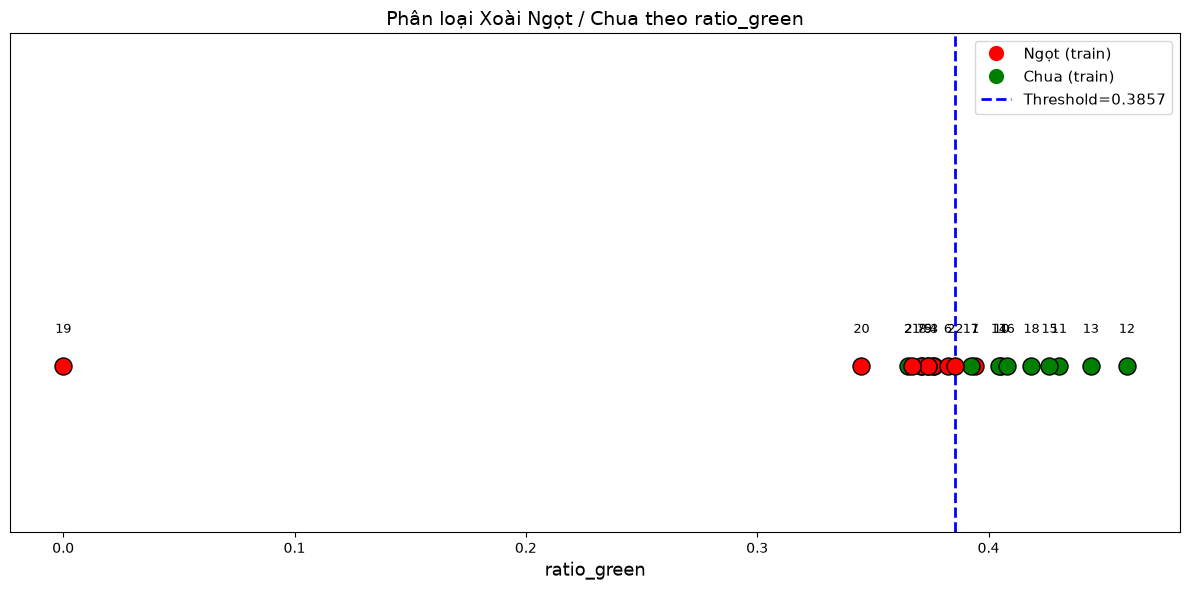


File         |  ratio_green | Dự đoán  | Nhãn thật  | Kết quả
1.jpg        |       0.3942 | Chua     | Ngọt       | ❌
2.jpg        |       0.3654 | Ngọt     | Chua       | ❌
3.png        |       0.3764 | Ngọt     | Ngọt       | ✅
4.png        |       0.3761 | Ngọt     | Ngọt       | ✅
5.png        |       0.3738 | Ngọt     | Ngọt       | ✅
6.png        |       0.3824 | Ngọt     | Ngọt       | ✅
7.png        |       0.3707 | Ngọt     | Ngọt       | ✅
8.png        |       0.3714 | Ngọt     | Ngọt       | ✅
9.png        |       0.3738 | Ngọt     | Ngọt       | ✅
10.png       |       0.4055 | Chua     | Chua       | ✅
11.png       |       0.4304 | Chua     | Chua       | ✅
12.png       |       0.4598 | Chua     | Chua       | ✅
13.png       |       0.4442 | Chua     | Chua       | ✅
14.png       |       0.4044 | Chua     | Chua       | ✅
15.png       |       0.4263 | Chua     | Chua       | ✅
16.png       |       0.4078 | Chua     | Chua       | ✅
17.png       |       0.3923 | Chua     | 

In [9]:
# ---- Tìm threshold cuối cùng trên toàn bộ train data ----
final_threshold, final_train_acc = find_best_threshold(all_features, all_labels)
print(f"Final threshold: {final_threshold:.4f}")
print(f"Train accuracy: {final_train_acc*100:.2f}%")

# ---- Vẽ đồ thị tổng hợp: Train + Test với threshold ----
fig, ax = plt.subplots(figsize=(12, 6))

for i, (rg, lbl, fname) in enumerate(zip(all_features, all_labels, image_files)):
    color = 'red' if lbl == 0 else 'green'
    ax.scatter(rg, 0, color=color, s=150, zorder=5, edgecolors='black')
    ax.annotate(fname.split('.')[0], (rg, 0.01), ha='center', fontsize=9)

# Vẽ đường threshold
ax.axvline(x=final_threshold, color='blue', linestyle='--', linewidth=2,
           label=f'Threshold = {final_threshold:.4f}')

ax.set_xlabel("ratio_green", fontsize=13)
ax.set_title("Phân loại Xoài Ngọt / Chua theo ratio_green", fontsize=14)
ax.set_yticks([])
ax.set_ylim(-0.05, 0.1)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',   markersize=12, label='Ngọt (train)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=12, label='Chua (train)'),
    Line2D([0], [0], color='blue', linewidth=2, linestyle='--', label=f'Threshold={final_threshold:.4f}'),
]
ax.legend(handles=legend_elements, fontsize=11)
plt.tight_layout()
plt.show()

# ---- Kiểm tra phân loại từng quả ----
print("\n" + "="*60)
print(f"{'File':<12} | {'ratio_green':>12} | {'Dự đoán':<8} | {'Nhãn thật':<10} | {'Kết quả'}")
print("="*60)
for rg, lbl, fname in zip(all_features, all_labels, image_files):
    pred = 1 if rg > final_threshold else 0
    ok = "✅" if pred == lbl else "❌"
    print(f"{fname:<12} | {rg:>12.4f} | {'Chua' if pred==1 else 'Ngọt':<8} | {'Chua' if lbl==1 else 'Ngọt':<10} | {ok}")
